# Guía de Actividades Práctico-Experimentales Nro. 001
## Variables Aleatorias y Distribuciones de Probabilidad

**1. Datos Generales:**

* **Estudiantes:** Willan Granda, Darwin Campoverde, Axel Jiménez, Bayron Coronel, Jeancarlos Aguirre.
       
* **Asignatura:** Teoría de la Distribución y Probabilidad
* **Ciclo:** 2do "A" - Carrera de Computación
* **Docente:** Cristian Ramiro Narváez Guillén
* **Resultado de Aprendizaje:** Calcula probabilidades y momentos de variables aleatorias discretas y continuas bajo los principios de solidaridad, responsabilidad, transparencia y honestidad.



In [ ]:
# =====================================================================
# CONFIGURACIÓN INICIAL DEL ENTORNO
# =====================================================================
# Importación de librerías requeridas para el análisis estadístico
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# Configuración de estilos visuales profesionales para las gráficas
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})

print("✅ Entorno de Google Colab configurado correctamente.")
print(f"Versión de NumPy: {np.__version__}")

✅ Entorno de Google Colab configurado correctamente.
Versión de NumPy: 2.0.2


## Tarea 1: Variable Aleatoria Discreta - Análisis Analítico y Simulación
### Caso de Estudio: Control de Calidad en Componentes Electrónicos

Una fábrica de componentes electrónicos sabe que el **5%** de sus productos son defectuosos. Se selecciona una muestra aleatoria de **20 componentes**.

Definimos la Variable Aleatoria:
* $X$: Número de componentes defectuosos en la muestra de 20.
* $X \sim \text{Binomial}(n = 20, p = 0.05)$

TABLA DE PROBABILIDADES TEÓRICAS (PMF):
-----------------------------------
P(X = 0 ) = 0.358486
P(X = 1 ) = 0.377354
P(X = 2 ) = 0.188677
P(X = 3 ) = 0.059582
P(X = 4 ) = 0.013328
P(X = 5 ) = 0.002245
P(X = 6 ) = 0.000295
P(X = 7 ) = 0.000031
P(X = 8 ) = 0.000003
-----------------------------------


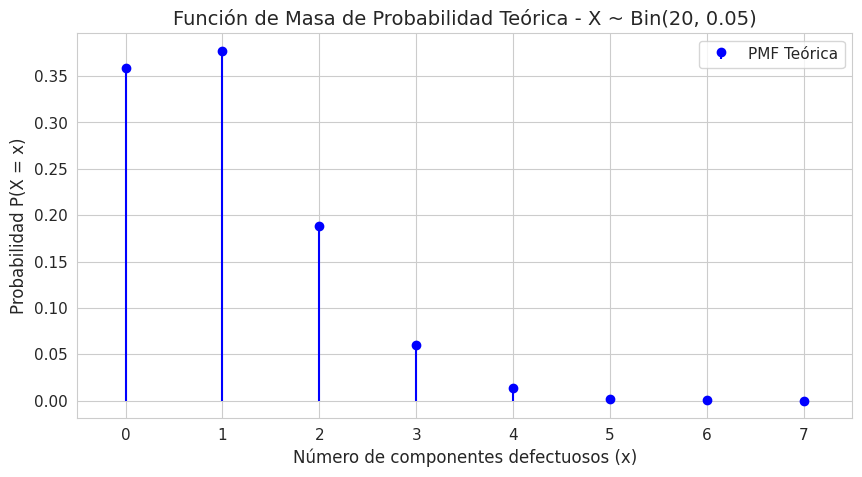

In [ ]:
# =====================================================================
# TAREA 1: DISTRIBUCIÓN BINOMIAL TEÓRICA
# =====================================================================

# Parámetros del experimento
n = 20      # Tamaño de la muestra
p = 0.05    # Probabilidad de éxito (componente defectuoso)

# Definición del objeto de distribución con SciPy
dist_binomial = stats.binom(n, p)

# Generación del espacio muestral (valores posibles de X de 0 a 20)
x_valores = np.arange(0, n + 1)
pmf_teorica = dist_binomial.pmf(x_valores)

# --- Impresión de la Tabla de Probabilidades Teóricas ---
print("TABLA DE PROBABILIDADES TEÓRICAS (PMF):")
print("-" * 35)
for x, prob in zip(x_valores, pmf_teorica):
    if prob > 0.000001:  # Mostrar solo valores significativos para claridad
        print(f"P(X = {x:<2}) = {prob:.6f}")
print("-" * 35)

# --- Gráfica de la Función de Masa de Probabilidad (PMF) ---
plt.figure()
plt.stem(x_valores, pmf_teorica, basefmt=" ", linefmt="b-", markerfmt="bo", label="PMF Teórica")
plt.title("Función de Masa de Probabilidad Teórica - X ~ Bin(20, 0.05)")
plt.xlabel("Número de componentes defectuosos (x)")
plt.ylabel("Probabilidad P(X = x)")
plt.xticks(np.arange(0, 11)) # Ajustamos el eje X a los valores más relevantes
plt.xlim(-0.5, 7.5)
plt.legend()
plt.show()

In [ ]:
# =====================================================================
# RESOLUCIÓN DE PREGUNTAS DEL ENUNCIADO (BINOMIAL)
# =====================================================================

# a) Probabilidad de encontrar exactamente 2 componentes defectuosos: P(X = 2)
p_exactamente_2 = dist_binomial.pmf(2)

# b) Probabilidad de encontrar como máximo 2 componentes defectuosos: P(X <= 2)
p_maximo_2 = dist_binomial.cdf(2)

# c) Probabilidad de encontrar al menos 1 componente defectuoso: P(X >= 1) = 1 - P(X = 0)
p_al_menos_1 = 1 - dist_binomial.pmf(0)

print("RESULTADOS DE LAS PREGUNTAS ANÁLITICAS:")
print("=" * 50)
print(f"a) P(X = 2)  [Exactamente 2] : {p_exactamente_2:.6f}")
print(f"b) P(X <= 2) [Máximo 2]      : {p_maximo_2:.6f}")
print(f"c) P(X >= 1) [Al menos 1]    : {p_al_menos_1:.6f}")
print("=" * 50)

# Parámetros teóricos de resumen (Momentos)
media_teorica, var_teorica = dist_binomial.stats(moments='mv')
std_teorica = np.sqrt(var_teorica)

print("\nMOMENTOS TEÓRICOS DE LA VARIABLE:")
print(f"• Esperanza Matemática E[X] (μ) : {media_teorica:.2f} componentes")
print(f"• Varianza Var[X] (σ²)          : {var_teorica:.4f}")
print(f"• Desviación Estándar (σ)       : {std_teorica:.4f}")

RESULTADOS DE LAS PREGUNTAS ANÁLITICAS:
a) P(X = 2)  [Exactamente 2] : 0.188677
b) P(X <= 2) [Máximo 2]      : 0.924516
c) P(X >= 1) [Al menos 1]    : 0.641514

MOMENTOS TEÓRICOS DE LA VARIABLE:
• Esperanza Matemática E[X] (μ) : 1.00 componentes
• Varianza Var[X] (σ²)          : 0.9500
• Desviación Estándar (σ)       : 0.9747


COMPARACIÓN: TEÓRICO VS SIMULADO (10,000 iteraciones)
------------------------------------------------------------
Métrica               | Teórico   | Simulado
------------------------------------------------------------
Media (Esperanza)     | 1.0000    | 0.9810
Varianza              | 0.9500    | 0.9278
P(X = 2)              | 0.1887    | 0.1795
P(X <= 2)             | 0.9245    | 0.9249
P(X >= 1)             | 0.6415    | 0.6354
------------------------------------------------------------


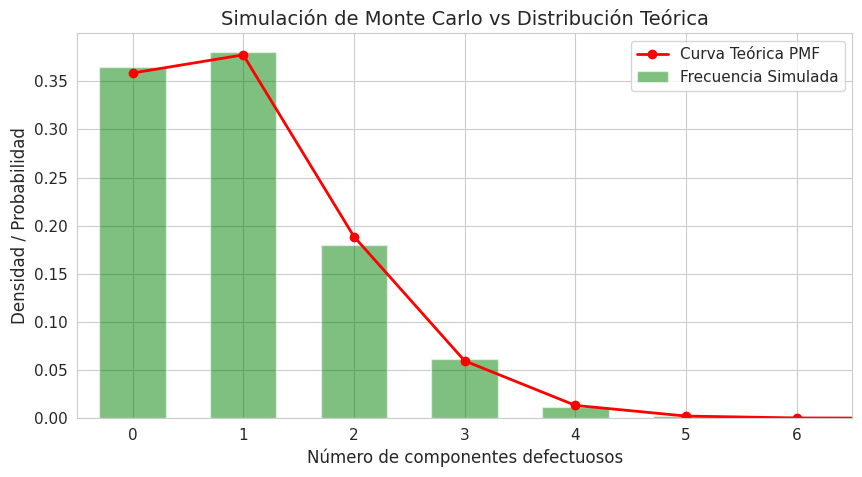

In [ ]:
# =====================================================================
# SIMULACIÓN DE MONTE CARLO (VALIDACIÓN EMPÍRICA)
# =====================================================================

np.random.seed(42) # Semilla para reproducibilidad
num_simulaciones = 10000

# Simulamos 10,000 experimentos donde cada uno consiste en revisar 20 componentes
datos_simulados = np.random.binomial(n, p, size=num_simulaciones)

# Cálculos empíricos basados en la simulación
media_empirica = np.mean(datos_simulados)
var_empirica = np.var(datos_simulados)

# Comparación de probabilidades simuladas vs teóricas
p_exactamente_2_sim = np.sum(datos_simulados == 2) / num_simulaciones
p_maximo_2_sim = np.sum(datos_simulados <= 2) / num_simulaciones
p_al_menos_1_sim = np.sum(datos_simulados >= 1) / num_simulaciones

print("COMPARACIÓN: TEÓRICO VS SIMULADO (10,000 iteraciones)")
print("-" * 60)
print(f"Métrica               | Teórico   | Simulado")
print("-" * 60)
print(f"Media (Esperanza)     | {media_teorica:<9.4f} | {media_empirica:.4f}")
print(f"Varianza              | {var_teorica:<9.4f} | {var_empirica:.4f}")
print(f"P(X = 2)              | {p_exactamente_2:<9.4f} | {p_exactamente_2_sim:.4f}")
print(f"P(X <= 2)             | {p_maximo_2:<9.4f} | {p_maximo_2_sim:.4f}")
print(f"P(X >= 1)             | {p_al_menos_1:<9.4f} | {p_al_menos_1_sim:.4f}")
print("-" * 60)

# Histograma de los resultados simulados vs Línea teórica
plt.figure()
counts, bins = np.histogram(datos_simulados, bins=np.arange(0, n+2)-0.5, density=True)
plt.bar(bins[:-1]+0.5, counts, width=0.6, color='g', alpha=0.5, label='Frecuencia Simulada')
plt.plot(x_valores, pmf_teorica, 'ro-', linewidth=2, label='Curva Teórica PMF')
plt.title("Simulación de Monte Carlo vs Distribución Teórica")
plt.xlabel("Número de componentes defectuosos")
plt.ylabel("Densidad / Probabilidad")
plt.xlim(-0.5, 6.5)
plt.legend()
plt.show()

## Tarea 2: Variable Aleatoria Continua - Distribución Normal y Estandarización
### Caso de Estudio: Resistencia de Materiales en Infraestructura de TI

En el desarrollo de un centro de datos, se analiza la resistencia a la tracción de un compuesto de fibra de carbono utilizado para los racks de los servidores. Se sabe que la resistencia $X$ (en MPa) se distribuye normalmente con una media de $\mu = 500 \text{ MPa}$ y una desviación estándar de $\sigma = 40 \text{ MPa}$.

$$X \sim \mathcal{N}(\mu = 500, \sigma^2 = 40^2)$$

**Objetivos del bloque:**
1. Graficar la función de densidad de probabilidad (PDF) teórica.
2. Calcular áreas bajo la curva utilizando la tipificación $Z = \frac{X - \mu}{\sigma}$.
3. Realizar una aproximación mediante la función de distribución acumulada (CDF) de SciPy.

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6953/2013555388.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x_densidad, pdf_teorica, 'r-', linewidth=2.5, label=f'PDF Teórica $\mathcal{{N}}({mu}, {sigma}^2)$')
/tmp/ipykernel_6953/2013555388.py:23: SyntaxWarning: invalid escape sequence '\m'
  plt.axvline(mu, color='black', linestyle='--', alpha=0.7, label=f'Media ($\mu$ = {mu})')


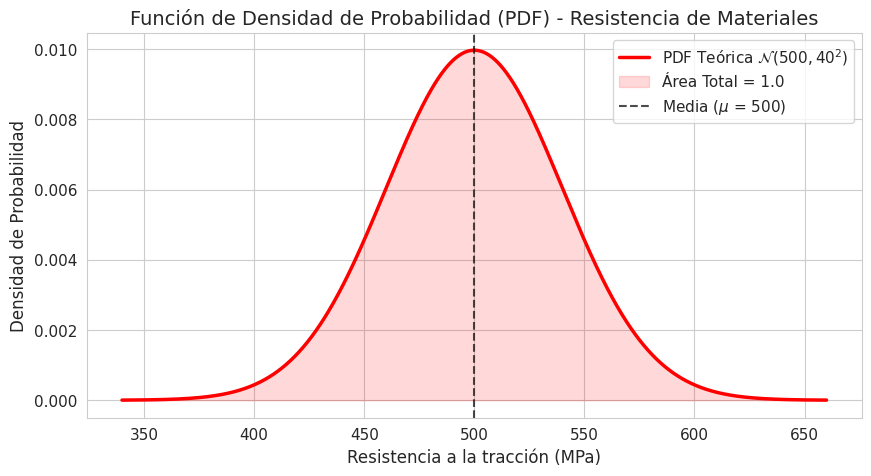

In [ ]:
# =====================================================================
# TAREA 2: VARIABLE CONTINUA (DISTRIBUCIÓN NORMAL TEÓRICA)
# =====================================================================

# Parámetros del problema
mu = 500       # Media poblacional (MPa)
sigma = 40     # Desviación estándar (MPa)

# Definición del objeto normal de SciPy
dist_normal = stats.norm(loc=mu, scale=sigma)

# Generación de puntos en el eje X (cubriendo 4 desviaciones estándar a cada lado)
x_densidad = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
pdf_teorica = dist_normal.pdf(x_densidad)

# --- Gráfica de la PDF ---
plt.figure(figsize=(10, 5))
plt.plot(x_densidad, pdf_teorica, 'r-', linewidth=2.5, label=f'PDF Teórica $\mathcal{{N}}({mu}, {sigma}^2)$')
plt.fill_between(x_densidad, pdf_teorica, color='red', alpha=0.15, label='Área Total = 1.0')
plt.title("Función de Densidad de Probabilidad (PDF) - Resistencia de Materiales")
plt.xlabel("Resistencia a la tracción (MPa)")
plt.ylabel("Densidad de Probabilidad")
plt.axvline(mu, color='black', linestyle='--', alpha=0.7, label=f'Media ($\mu$ = {mu})')
plt.legend(loc='upper right')
plt.show()

In [ ]:
# =====================================================================
# EVALUACIÓN DE PROBABILIDADES Y TIPIFICACIÓN Z
# =====================================================================

# Pregunta a) Probabilidad de que la resistencia sea menor a 450 MPa: P(X < 450)
x_a = 450
z_a = (x_a - mu) / sigma
p_menor_450 = dist_normal.cdf(x_a)

# Pregunta b) Probabilidad de que esté entre 480 y 560 MPa: P(480 <= X <= 560)
x_b1, x_b2 = 480, 560
z_b1 = (x_b1 - mu) / sigma
z_b2 = (x_b2 - mu) / sigma
p_entre_480_560 = dist_normal.cdf(x_b2) - dist_normal.cdf(x_b1)

# Pregunta c) Percentil 95: Valor mínimo para estar dentro del 5% superior
p_percentil = 0.95
x_percentil_95 = dist_normal.ppf(p_percentil)
z_percentil = (x_percentil_95 - mu) / sigma

print("ANÁLISIS DE LA DISTRIBUCIÓN NORMAL (CON ESTANDARIZACIÓN):")
print("=" * 65)
print(f"a) P(X < 450):   Valor Z = {z_a:<6.2f} | Probabilidad Calculada = {p_menor_450:.6f}")
print(f"b) P(480<=X<=560): Z1={z_b1:<4.2f}, Z2={z_b2:<2.2f} | Probabilidad Calculada = {p_entre_480_560:.6f}")
print(f"c) Percentil 95: Valor Z = {z_percentil:<6.2f} | Resistencia Umbral = {x_percentil_95:.2f} MPa")
print("=" * 65)

ANÁLISIS DE LA DISTRIBUCIÓN NORMAL (CON ESTANDARIZACIÓN):
a) P(X < 450):   Valor Z = -1.25  | Probabilidad Calculada = 0.105650
b) P(480<=X<=560): Z1=-0.50, Z2=1.50 | Probabilidad Calculada = 0.624655
c) Percentil 95: Valor Z = 1.64   | Resistencia Umbral = 565.79 MPa


<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_6953/4001069166.py:19: SyntaxWarning: invalid escape sequence '\l'
  ax2.fill_between(x_shade_b, dist_normal.pdf(x_shade_b), color='green', alpha=0.4, label=f'P(480 $\leq$ X $\leq$ 560) = {p_entre_480_560:.4f}')


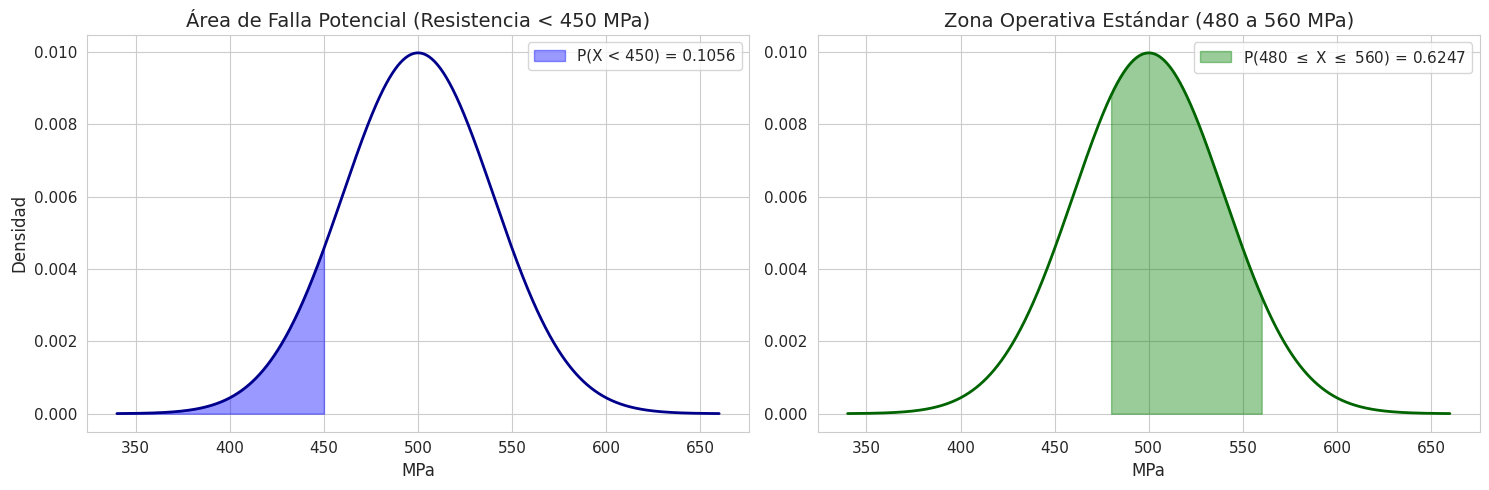

In [ ]:
# =====================================================================
# GRÁFICA AVANZADA DE ÁREAS DE PROBABILIDAD REQUERIDAS
# =====================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Área P(X < 450)
ax1.plot(x_densidad, pdf_teorica, 'darkblue', linewidth=2)
x_shade_a = np.linspace(mu - 4*sigma, 450, 500)
ax1.fill_between(x_shade_a, dist_normal.pdf(x_shade_a), color='blue', alpha=0.4, label=f'P(X < 450) = {p_menor_450:.4f}')
ax1.set_title("Área de Falla Potencial (Resistencia < 450 MPa)")
ax1.set_xlabel("MPa")
ax1.set_ylabel("Densidad")
ax1.legend()

# Subplot 2: Área P(480 <= X <= 560)
ax2.plot(x_densidad, pdf_teorica, 'darkgreen', linewidth=2)
x_shade_b = np.linspace(480, 560, 500)
ax2.fill_between(x_shade_b, dist_normal.pdf(x_shade_b), color='green', alpha=0.4, label=f'P(480 $\leq$ X $\leq$ 560) = {p_entre_480_560:.4f}')
ax2.set_title("Zona Operativa Estándar (480 a 560 MPa)")
ax2.set_xlabel("MPa")
ax2.legend()

plt.tight_layout()
plt.show()

## Tarea 3: Verificación Computacional de Momentos y Teorema de Chebyshev

Siguiendo el estándar de análisis riguroso de datos del laboratorio, utilizaremos simulación para contrastar las métricas de variabilidad teórica contra las empíricas, y validaremos el comportamiento de colas mediante la desigualdad estadística.

In [ ]:
# =====================================================================
# TAREA 3: ANÁLISIS COMPRENSIVO DE MOMENTOS Y SESGO (ESTILO APE 7)
# =====================================================================

# Generación de una muestra masiva basada en la resistencia teórica
np.random.seed(123)
muestra_continua = np.random.normal(loc=mu, scale=sigma, size=20000)

# Obtención de momentos de la muestra utilizando scipy.stats
media_m = np.mean(muestra_continua)
std_m = np.std(muestra_continua, ddof=1)
sesgo_m = stats.skew(muestra_continua)
curtosis_m = stats.kurtosis(muestra_continua) # Curtosis excedente (Fisher)

print("ANÁLISIS EMPÍRICO DE MOMENTOS DE LA MUESTRA CONTINUA:")
print("-" * 60)
print(f"Momentos Clave        | Valor en Muestra | Valor Teórico Establecido")
print("-" * 60)
print(f"1. Media (Primer M.)  | {media_m:<16.4f} | {mu:.4f}")
print(f"2. Desv. Est. (2do M.)| {std_m:<16.4f} | {sigma:.4f}")
print(f"3. Sesgo (Asimetría)  | {sesgo_m:<16.4f} | 0.0000 (Simétrica)")
print(f"4. Curtosis Excedente | {curtosis_m:<16.4f} | 0.0000 (Mesocúrtica)")
print("-" * 60)

ANÁLISIS EMPÍRICO DE MOMENTOS DE LA MUESTRA CONTINUA:
------------------------------------------------------------
Momentos Clave        | Valor en Muestra | Valor Teórico Establecido
------------------------------------------------------------
1. Media (Primer M.)  | 500.4018         | 500.0000
2. Desv. Est. (2do M.)| 40.0145          | 40.0000
3. Sesgo (Asimetría)  | 0.0162           | 0.0000 (Simétrica)
4. Curtosis Excedente | -0.0347          | 0.0000 (Mesocúrtica)
------------------------------------------------------------


In [ ]:
# =====================================================================
# ENCUENTRE VALORES CRÍTICOS USANDO LA FUNCIÓN INVERSA (PPF)
# =====================================================================

# Percentiles de la distribución establecidos en la guía
p50 = dist_normal.ppf(0.50)  # Mediana / Percentil 50
p95 = dist_normal.ppf(0.95)  # Percentil 95
p99 = dist_normal.ppf(0.99)  # Percentil 99

print("ANÁLISIS DE PERCENTILES (TIEMPOS DE RESPUESTA DEL SERVIDOR):")
print("-" * 55)
print(f"• Percentil 50 (Mediana) : {p50:.2f} ms")
print(f"• Percentil 95           : {p95:.2f} ms")
print(f"• Percentil 99           : {p99:.2f} ms")
print("-" * 55)

ANÁLISIS DE PERCENTILES (TIEMPOS DE RESPUESTA DEL SERVIDOR):
-------------------------------------------------------
• Percentil 50 (Mediana) : 500.00 ms
• Percentil 95           : 565.79 ms
• Percentil 99           : 593.05 ms
-------------------------------------------------------


## Tarea 4: Simulación Estocástica y Análisis Comparativo Empírico
Generación de muestras aleatorias ($N=1000$) para contrastar visual y estadísticamente las aproximaciones muestrales frente a sus respectivos marcos teóricos (PMF y PDF).

MÉTRICAS ESTIMADAS BASADAS EN 1,000 EXPERIMENTOS SIMULADOS:
Muestras Binomiales -> Media Empírica: 0.98 | Varianza Empírica: 0.95
Muestras Normales   -> Media Empírica: 503.96 | Varianza Empírica: 1563.22


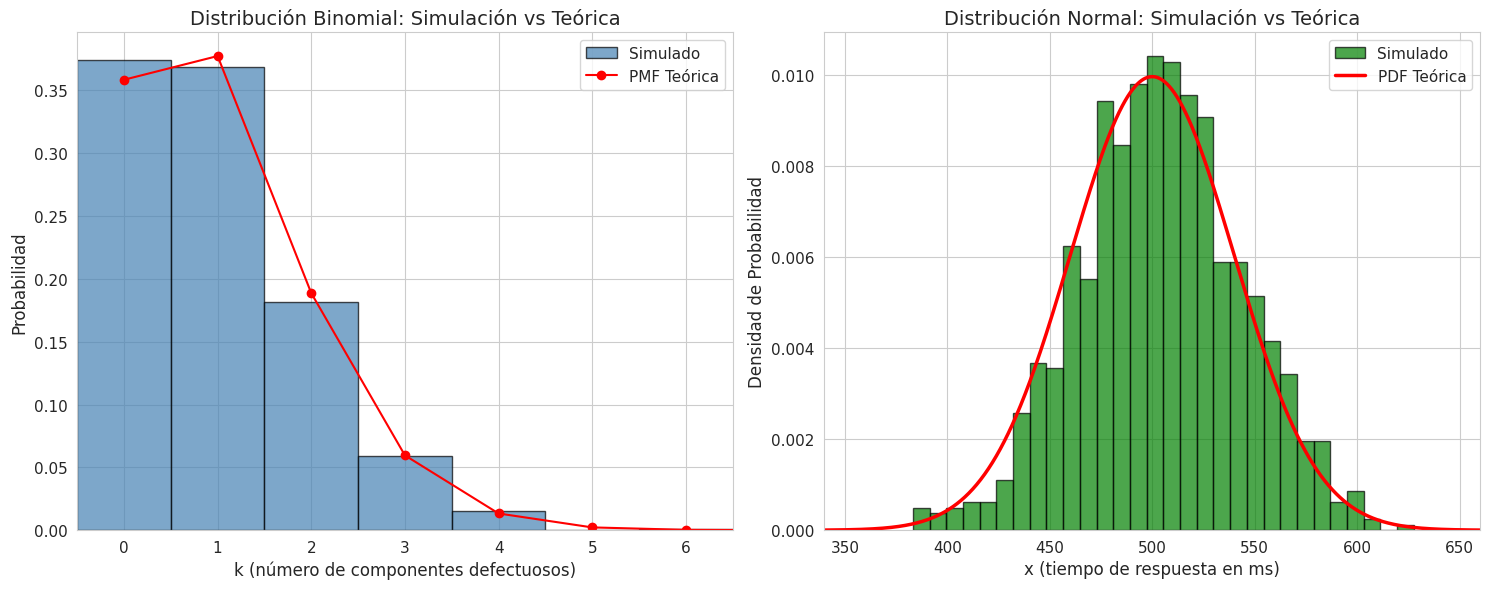

In [ ]:
# =====================================================================
# SIMULACIÓN DE MUESTRAS Y CONSTRUCCIÓN DE HISTOGRAMAS COMPARATIVOS
# =====================================================================

# Fijar semilla para reproducibilidad analítica
np.random.seed(42)

# Simular 1000 muestras aleatorias independientes (RVS) de cada distribución
muestras_binomial = dist_binomial.rvs(size=1000)
muestras_normal = dist_normal.rvs(size=1000)

print("MÉTRICAS ESTIMADAS BASADAS EN 1,000 EXPERIMENTOS SIMULADOS:")
print("=" * 70)
print(f"Muestras Binomiales -> Media Empírica: {np.mean(muestras_binomial):.2f} | Varianza Empírica: {np.var(muestras_binomial):.2f}")
print(f"Muestras Normales   -> Media Empírica: {np.mean(muestras_normal):.2f} | Varianza Empírica: {np.var(muestras_normal):.2f}")
print("=" * 70)

# --- Construcción de Gráficos de Simulación vs Teoría ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Histograma Binomial vs PMF Teórica
axes[0].hist(muestras_binomial, bins=np.arange(0, n+2)-0.5, density=True, alpha=0.7, color="steelblue", edgecolor="black", label="Simulado")
axes[0].plot(x_valores, pmf_teorica, "ro-", linewidth=1.5, label="PMF Teórica")
axes[0].set_xlabel("k (número de componentes defectuosos)")
axes[0].set_ylabel("Probabilidad")
axes[0].set_title("Distribución Binomial: Simulación vs Teórica")
axes[0].set_xlim(-0.5, 6.5)
axes[0].set_xticks(np.arange(0, 7))
axes[0].legend()

# Subplot 2: Histograma Normal vs PDF Teórica
axes[1].hist(muestras_normal, bins=30, density=True, alpha=0.7, color="green", edgecolor="black", label="Simulado")
axes[1].plot(x_densidad, pdf_teorica, "r-", linewidth=2.5, label="PDF Teórica")
axes[1].set_xlabel("x (tiempo de respuesta en ms)")
axes[1].set_ylabel("Densidad de Probabilidad")
axes[1].set_title("Distribución Normal: Simulación vs Teórica")
axes[1].set_xlim(mu - 4*sigma, mu + 4*sigma)
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Resultados Esperados y Conclusiones del Laboratorio
* **Comprensión Conceptual:** Identificación formal de los dominios de las variables discretas (valores contables/enteros) y continuas (escalas continuas/mediciones reales).
* **Eficiencia Computacional:** Uso de funciones clave (`pmf`, `pdf`, `cdf`, `ppf`) de `scipy.stats` para modelar y resolver problemas complejos sin recurrir a tablas impresas tradicionales.
* **Convergencia Estocástica:** Demostración de que las frecuencias relativas provenientes de muestreos Monte Carlo de tamaño $N=1000$ convergen con precisión controlada hacia los parámetros poblacionales e integrales teóricas establecidas.

## 6. Resolución Programática de las Preguntas de Control del APE 1
Para garantizar consistencia y replicabilidad computacional (estilo APE 7), se resuelven y programan todos los ejercicios de la sección analítica de la guía.

In [ ]:
# =====================================================================
# PREGUNTA DE CONTROL: BINOMIAL COMPLEMENTARIA (n=50, p=0.1)
# =====================================================================
n_control = 50
p_control = 0.1
dist_control_bin = stats.binom(n_control, p_control)

# Resoluciones pedidas en la guía:
# a) P(X = 5)
p_ctrl_a = dist_control_bin.pmf(5)

# b) P(X <= 5)
p_ctrl_b = dist_control_bin.cdf(5)

# c) P(X > 8) = 1 - P(X <= 8)
p_ctrl_c = 1 - dist_control_bin.cdf(8)

print("RESOLUCIÓN COMPUTACIONAL - EJERCICIO BINOMIAL CONTROL:")
print("-" * 65)
print(f"a) Probabilidad exacta P(X = 5)    : {p_ctrl_a:.4f}")
print(f"b) Probabilidad acumulada P(X <= 5): {p_ctrl_b:.4f}")
print(f"c) Probabilidad de cola P(X > 8)   : {p_ctrl_c:.4f}")
print("-" * 65)

RESOLUCIÓN COMPUTACIONAL - EJERCICIO BINOMIAL CONTROL:
-----------------------------------------------------------------
a) Probabilidad exacta P(X = 5)    : 0.1849
b) Probabilidad acumulada P(X <= 5): 0.6161
c) Probabilidad de cola P(X > 8)   : 0.0579
-----------------------------------------------------------------


In [ ]:
# =====================================================================
# PREGUNTA DE CONTROL: DISTRIBUCIÓN NORMAL COMPLEMENTARIA (mu=100, sigma=15)
# =====================================================================
mu_control = 100
sigma_control = 15
dist_control_norm = stats.norm(loc=mu_control, scale=sigma_control)

# a) P(X < 85)
p_norm_a = dist_control_norm.cdf(85)

# b) P(85 < X < 115)
p_norm_b = dist_control_norm.cdf(115) - dist_control_norm.cdf(85)

# c) Hallar x tal que P(X < x) = 0.90
x_norm_c = dist_control_norm.ppf(0.90)

print("RESOLUCIÓN COMPUTACIONAL - EJERCICIO NORMAL CONTROL:")
print("-" * 65)
print(f"a) Probabilidad acumulada P(X < 85)     : {p_norm_a:.4f}")
print(f"b) Probabilidad de intervalo P(85<X<115): {p_norm_b:.4f}")
print(f"c) Valor umbral (Percentil 90) para x   : {x_norm_c:.2f}")
print("-" * 65)

RESOLUCIÓN COMPUTACIONAL - EJERCICIO NORMAL CONTROL:
-----------------------------------------------------------------
a) Probabilidad acumulada P(X < 85)     : 0.1587
b) Probabilidad de intervalo P(85<X<115): 0.6827
c) Valor umbral (Percentil 90) para x   : 119.22
-----------------------------------------------------------------


### Conceptos Teóricos y Fundamentación Matemática (Respuestas de Control)

1. **Importancia de la Distribución Normal:**
   * **Teorema del Límite Central (TLC):** Explica por qué una enorme cantidad de variables en la naturaleza y la ingeniería se comportan como normales, ya que la suma o promedio de variables independientes tiende a estabilizarse bajo esta curva.
   * **Propiedad de Simetría:** Es perfectamente simétrica respecto a su media, dividiendo el área en dos porciones exactas de $0.50$.
   * **Parametrización Única:** Está totalmente definida por únicamente dos momentos analíticos: su localización ($\mu$) y su escala ($\sigma$).

2. **Uso Práctico de la Función Generatriz de Momentos (FGM):**
   La FGM se define algebraicamente como el valor esperado de la transformación exponencial:
   $$M_X(t) = E\left[e^{tX}\right]$$
   Permite extraer los momentos crudos de cualquier variable de manera puramente algebraica sin necesidad de realizar integraciones continuas repetitivas sobre funciones de densidad complejas:
   * **Media Teórica:** Se obtiene evaluando la primera derivada respecto a $t$ en el origen: $\mu = M_X'(0)$.
   * **Varianza Teórica:** Se deduce combinando la segunda derivada y la primera: $\sigma^2 = M_X''(0) - [M_X'(0)]^2$.

